In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step1: Load the data

In [2]:
def load_cleaned_data(station_id, directory="../EDA_2025/cleaned_data"):
    filename = f"{directory}/Station{station_id}_cleaned_data.csv"
    df = pd.read_csv(filename, parse_dates=True, index_col=0)
    df.index = pd.DatetimeIndex(df.index)
    df.index.freq = 'H'
    return df

def load_missing_data(station_id, directory="../EDA_2025/missing_data"):
    filename = f"{directory}/Station{station_id}_missing_data.csv"
    df = pd.read_csv(filename, parse_dates=["Start Timestamp", "End Timestamp"])
    return df

### Step2: Filter Short gap data (Hours to Days) (<24 hours)

In [3]:
def filter_short_gaps(gap_df, parameter, max_gap = 24):
    gap_df["Number Missing"] = pd.to_numeric(gap_df["Number Missing"], errors="coerce")
    mask = (gap_df["Parameter"] == parameter) & (gap_df["Number Missing"] < max_gap)
    return gap_df[mask].copy()

### Method 1: Interpolation

In [4]:
def fill_by_interpolation(series, start_ts, end_ts):
    s = series.copy()
    s[start_ts:end_ts] = np.nan
    s = s.interpolate(method="time")
    return s.loc[start_ts:end_ts]

### Method 2: KNN

In [5]:
def fill_by_knn_hod(series, start_ts, end_ts, k=10, doy_radius=10):
    train = series.dropna()
    idx = pd.date_range(start_ts, end_ts, freq="H")
    if train.empty:
        return pd.Series(index=idx, dtype=float)

    df = pd.DataFrame({"y": train.values}, index=train.index)
    df["HOD"] = df.index.hour
    df["DOY"] = df.index.dayofyear

    preds = []
    for ts in idx:
        h = ts.hour; d = ts.dayofyear
        cand = df[df["HOD"] == h].copy()
        if cand.empty:
            preds.append(np.nan); continue
        cand["d"] = (cand["DOY"] - d).abs()
        cand = cand[cand["d"] <= doy_radius].nsmallest(k, "d")
        if len(cand) == 0:
            cand = df[df["HOD"] == h]  
        preds.append(float(cand["y"].median()))
    return pd.Series(preds, index=idx)


### Method 2: Moving Average

In [27]:
#def fill_by_moving_average(series, start_ts, end_ts, window = 3):
    #before = series.loc[start_ts - pd.Timedelta(hours=window): start_ts - pd.Timedelta(hours=1)].dropna()
    #after  = series.loc[end_ts   + pd.Timedelta(hours=1): end_ts   + pd.Timedelta(hours=window)].dropna()
    #combined = pd.concat([before, after])

    #if combined.empty:
        #fill_val = series.loc[: start_ts - pd.Timedelta(hours=1)].iloc[-1]
    #else:
        #fill_val = combined.mean()
        
    #idx = pd.date_range(start_ts, end_ts, freq="H")
    #return pd.Series(fill_val, index=idx)

### Step 4: Evaluate two methods

In [33]:
def plot_gap_continuous(series, start_ts, end_ts, interp_vals, knn_vals, window=6, title_prefix=""):
    # windowed view
    view = series.loc[start_ts - pd.Timedelta(hours=window) :
                      end_ts   + pd.Timedelta(hours=window)].copy()

    # build continuous "filled" curves by embedding predictions back
    interp_full = view.copy()
    knn_full    = view.copy()
    interp_full.loc[start_ts:end_ts] = interp_vals.values
    knn_full.loc[start_ts:end_ts]    = knn_vals.values

    # draw one chart (no explicit colors/styles per tool rules)
    plt.figure(figsize=(10,4))
    plt.plot(view, label="Original")
    plt.plot(interp_full, label="Interpolation (filled)")
    plt.plot(knn_full, label="kNN(HOD±DOY) (filled)")
    plt.axvspan(start_ts, end_ts, alpha=0.15)
    ttl = f"{title_prefix} {start_ts} → {end_ts}".strip()
    plt.title(ttl)
    plt.xlabel("Timestamp")
    plt.ylabel(series.name)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [34]:
def main(station_id=1, parameter="T_20", apply_method="Interpolation"):
    df   = load_cleaned_data(station_id)
    gaps = load_missing_data(station_id)
    short_gaps = filter_short_gaps(gaps, parameter)

    if short_gaps.empty:
        print(f"No short gaps (<24 h) for {parameter} at station {station_id}.")
        return

    print(f"Found {len(short_gaps)} short gaps for {parameter}.")

    for _, row in short_gaps.iterrows():
        start_ts = pd.to_datetime(row["Start Timestamp"])
        end_ts   = pd.to_datetime(row["End Timestamp"])

        # Two methods
        interp_vals = fill_by_interpolation(df[parameter], start_ts, end_ts)
        knn_vals    = fill_by_knn_hod(df[parameter], start_ts, end_ts, k=10, doy_radius=10)

        plot_gap_continuous(df[parameter], start_ts, end_ts, interp_vals, knn_vals)


        chosen = interp_vals if apply_method.lower().startswith("inter") else knn_vals
        df.loc[start_ts:end_ts, parameter] = chosen



Found 8 short gaps for SWC_20.


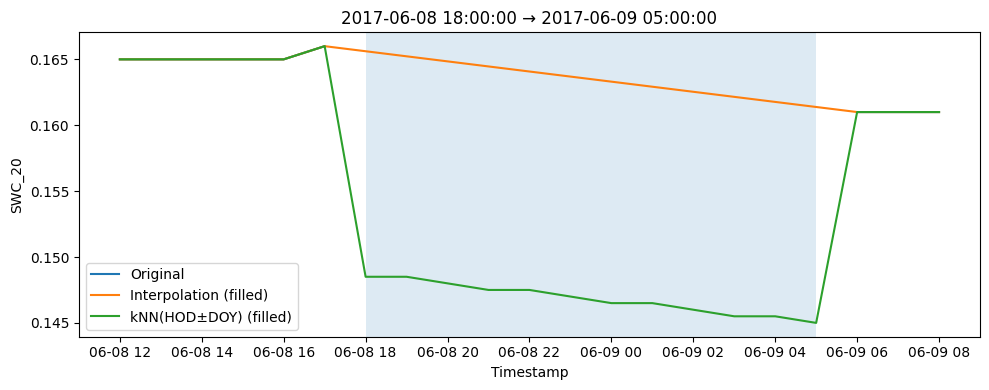

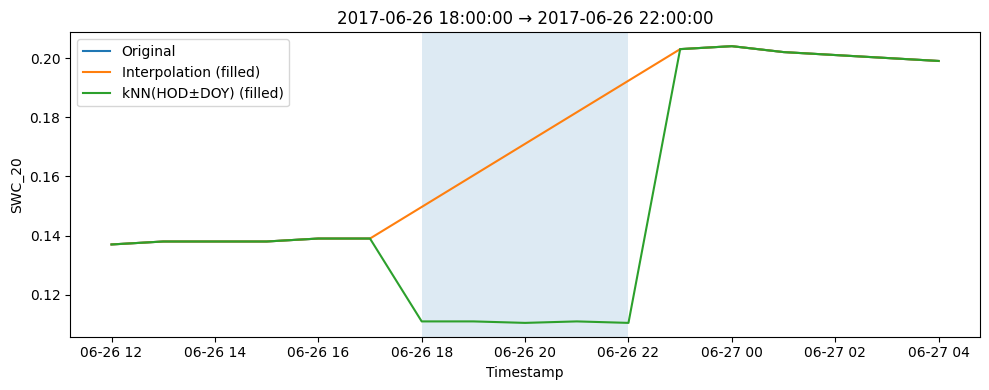

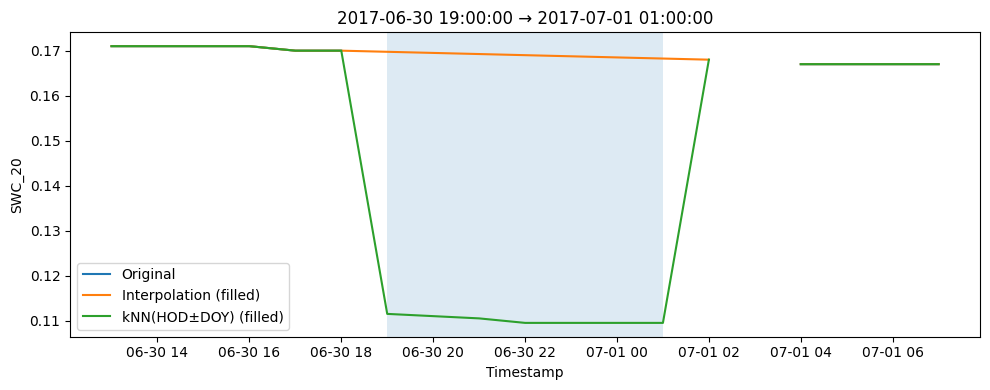

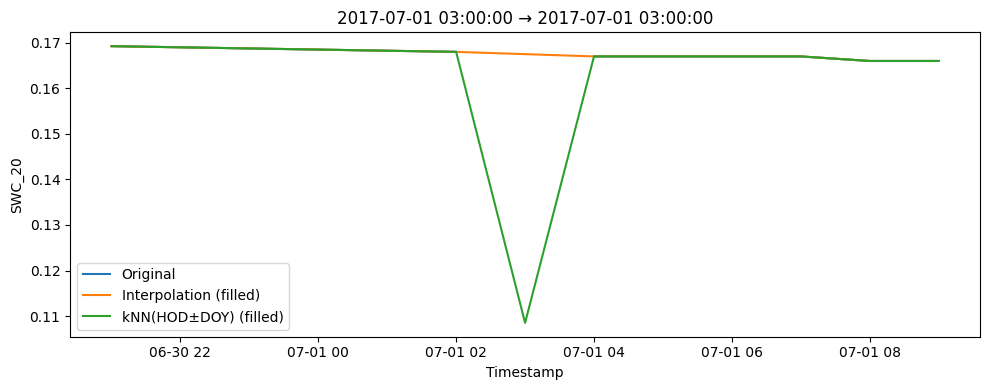

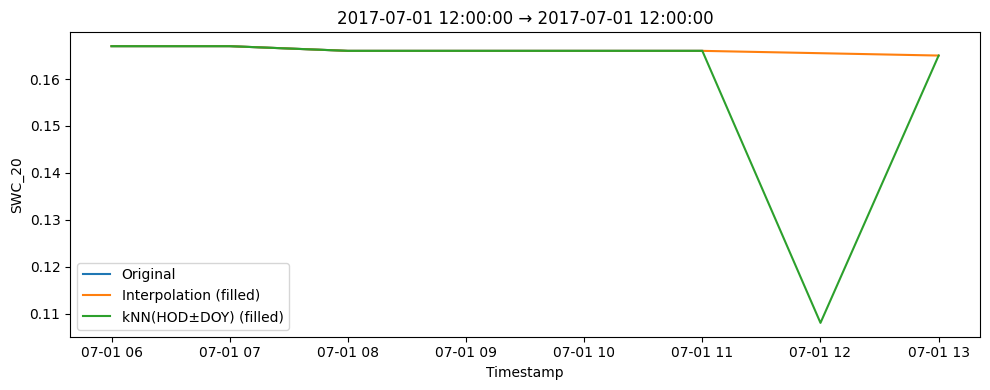

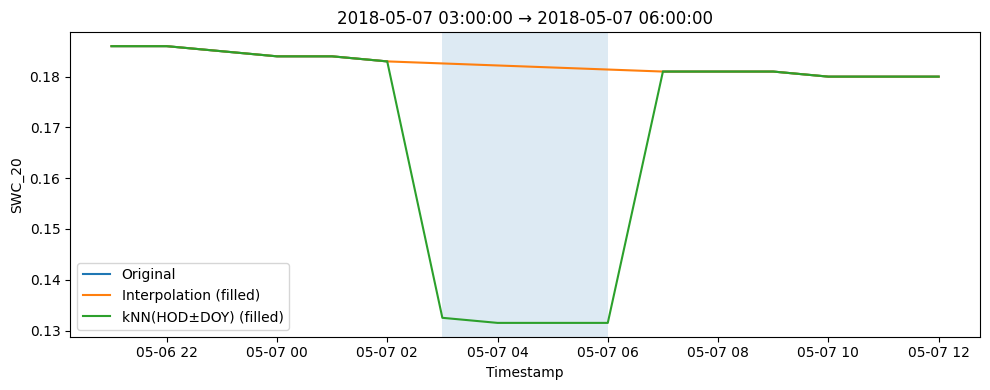

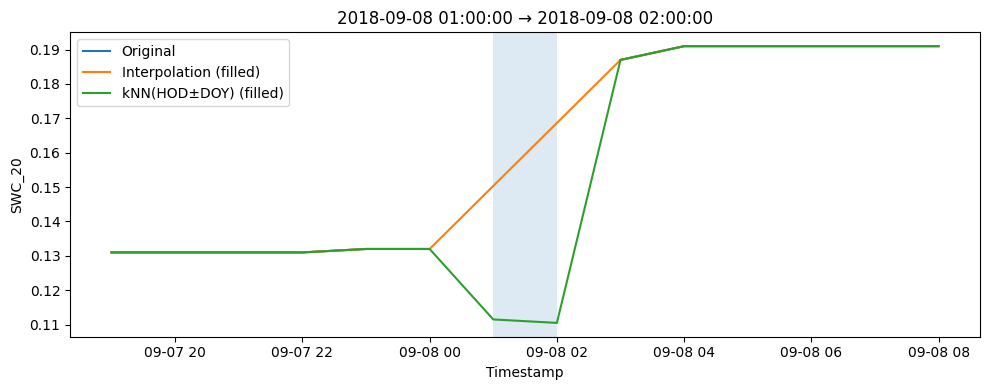

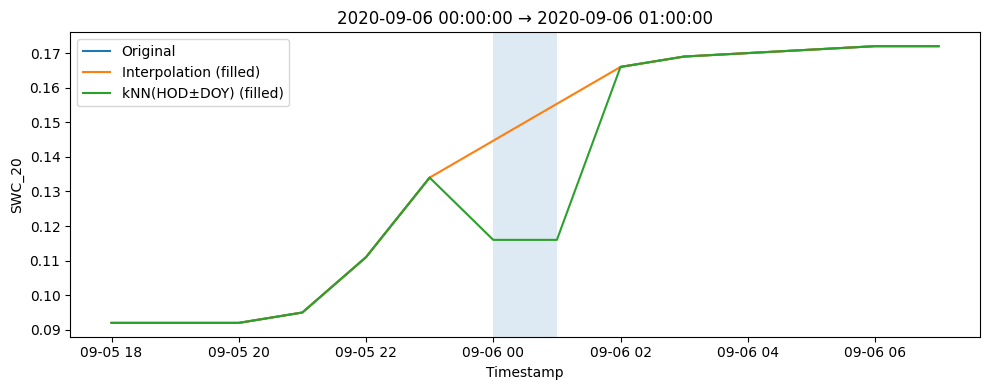

Found 1 short gaps for T_20.


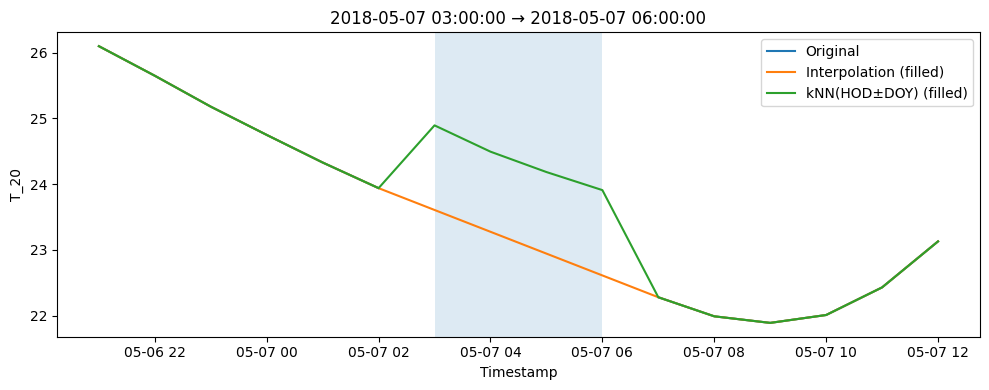

In [35]:
# Soil moisture
main(station_id=1, parameter="SWC_20", apply_method="Interpolation")
# Soil temperature
main(station_id=1, parameter="T_20",   apply_method="Interpolation")  

In [40]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

STATIONS   = [1, 2, 3, 4, 5, 6]
PARAMS     = ["SWC_5","SWC_10","SWC_20","SWC_50","T_5","T_10","T_20","T_50"] 
METHODS    = ["Interpolation", "kNN"]   
N_GAPS     = 10
GAP_H_MIN  = 4
GAP_H_MAX  = 12
rng        = np.random.default_rng(42)


def load_cleaned_data(station_id, directory="../EDA_2025/cleaned_data"):
    fn = Path(directory) / f"Station{station_id}_cleaned_data.csv"
    df = pd.read_csv(fn, parse_dates=True, index_col=0)
    
    df.index = pd.DatetimeIndex(df.index, freq="H")
    return df

def fill_by_knn_hod(series, start_ts, end_ts, k=10, doy_radius=10):

    train = series.dropna()
    idx = pd.date_range(start_ts, end_ts, freq="H")
    if train.empty:
        return pd.Series(index=idx, dtype=float)

    df = pd.DataFrame({"y": train.values}, index=train.index)
    df["HOD"] = df.index.hour
    df["DOY"] = df.index.dayofyear

    preds = []
    for ts in idx:
        h = ts.hour; d = ts.dayofyear
        cand = df[df["HOD"] == h].copy()
        if cand.empty:
            preds.append(np.nan); continue
        cand["d"] = (cand["DOY"] - d).abs()
        cand = cand[cand["d"] <= doy_radius].nsmallest(k, "d")
        if len(cand) == 0:                      
            cand = df[df["HOD"] == h]
        preds.append(float(cand["y"].median()))
    return pd.Series(preds, index=idx)

def punch_and_fill(series, n_gaps, rng, method="Interpolation"):

    s_gap   = series.copy()
    all_ts  = s_gap.index[~s_gap.isna()]
    punched = []


    if len(all_ts) <= (GAP_H_MIN + 2):
        return np.nan, np.nan, np.nan

    tries = 0
    max_tries = 5000

    # punch synthetic gaps
    while len(punched) < n_gaps and tries < max_tries:
        tries += 1

        max_len = min(GAP_H_MAX, max(GAP_H_MIN, len(all_ts) - 1))
        gap_len = int(rng.integers(GAP_H_MIN, max_len + 1))

        if len(all_ts) <= gap_len:
            break
        start = rng.choice(all_ts[:-gap_len])

        end = start + pd.Timedelta(hours=gap_len - 1)
        idx = pd.date_range(start, end, freq="H")

        if not idx.isin(s_gap.index).all():
            continue
        if s_gap.loc[idx].isna().any():
            continue

        punched.append((idx, s_gap.loc[idx].values.copy()))
        s_gap.loc[idx] = np.nan

    if len(punched) == 0:
        return np.nan, np.nan, np.nan
    if len(punched) < n_gaps:
        print(f"[warn] Requested {n_gaps} gaps, created {len(punched)} due to data constraints.")

    # interpolate / kNN 
    s_filled = s_gap.copy()
    if method == "Interpolation":
        s_filled = s_gap.interpolate(method="time")
    else:
        for idx, _ in punched:
            pred = fill_by_knn_hod(series, idx[0], idx[-1], k=10, doy_radius=10)
            s_filled.loc[idx] = pred.values

    # metrics
    maes, mses, rmses = [], [], []
    for idx, true_vals in punched:
        pred_vals = s_filled.loc[idx].values
        maes.append(mean_absolute_error(true_vals, pred_vals))
        mses.append(mean_squared_error(true_vals, pred_vals))
        rmses.append(mean_squared_error(true_vals, pred_vals, squared=False))
    return float(np.nanmean(maes)), float(np.nanmean(mses)), float(np.nanmean(rmses))

results = []
for sid in STATIONS:
    df = load_cleaned_data(sid)
    for PARAM in PARAMS:
        if PARAM not in df.columns:
            continue
        for M in METHODS:
            mae, mse, rmse = punch_and_fill(df[PARAM], N_GAPS, rng, method=M)
            results.append({"Station": sid, "Parameter": PARAM, "Method": M,
                            "MAE": mae, "MSE": mse, "RMSE": rmse})

res_df = pd.DataFrame(results)
display(res_df)

print("\nOverall average by Parameter × Method")
print(res_df.groupby(["Parameter","Method"])[["MAE","MSE","RMSE"]].mean())


C:\Users\13464\miniconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\13464\miniconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\13464\miniconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\13464\miniconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

,Station,Parameter,Method,MAE,MSE,RMSE
0,1,SWC_5,Interpolation,0.004388,1.695245e-04,0.005189
1,1,SWC_5,kNN,0.033567,3.028211e-03,0.033644
2,1,SWC_10,Interpolation,0.000642,8.914129e-07,0.000759
3,1,SWC_10,kNN,0.015250,6.721109e-04,0.015349
4,1,SWC_20,Interpolation,0.000479,3.900549e-07,0.000581
...,...,...,...,...,...,...
91,6,T_10,kNN,2.931104,1.350039e+01,3.013444
92,6,T_20,Interpolation,0.411239,3.452931e-01,0.445866
93,6,T_20,kNN,3.028387,1.355030e+01,3.039914
94,6,T_50,Interpolation,0.059985,6.169650e-03,0.064749



Overall average by Parameter × Method
                              MAE           MSE      RMSE
Parameter Method                                         
SWC_10    Interpolation  0.001189  1.095371e-05  0.001392
          kNN            0.023951  1.287617e-03  0.024079
SWC_20    Interpolation  0.000775  6.435091e-06  0.000874
          kNN            0.037115  2.950405e-03  0.037221
SWC_5     Interpolation  0.002642  7.904179e-05  0.002950
          kNN            0.037779  2.836320e-03  0.037945
SWC_50    Interpolation  0.000180  1.190855e-07  0.000209
          kNN            0.055096  6.652014e-03  0.055152
T_10      Interpolation  0.750184  1.240338e+00  0.821183
          kNN            2.481513  1.122362e+01  2.549696
T_20      Interpolation  0.305952  2.659794e-01  0.332993
          kNN            3.117472  3.422303e+01  3.138293
T_5       Interpolation  1.067860  2.699266e+00  1.179940
          kNN            2.403818  1.092139e+01  2.537662
T_50      Interpolation  0.034389